# XGBoost with Lagged Temporal Features

The professor's ask: *"XGBoost with lagged features over the last n months with increasing window size — last month, 6 months, year."*

For each purchase row we add features describing that customer's **prior purchase history**:

| Feature | Description |
|---------|-------------|
| `prev_parent_category` | Consolidated group of the customer's immediately prior purchase |
| `prev_price_tier` | Price tier (0/1/2) of the immediately prior purchase |
| `days_since_last` | Days between this purchase and the prior one |
| `n_prev_1mo` | Count of same-customer purchases in the prior calendar month |
| `n_prev_6mo` | Count in the prior 6 calendar months |
| `n_prev_12mo` | Count in the prior 12 calendar months |

These capture **customer purchase rhythm** — sequence information that a single-row model misses entirely.  
Baseline comparison: notebook 15-1 (same 15-class target, no lags) achieved **29.5% accuracy**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report
import warnings
warnings.filterwarnings('ignore')

print('Loading data...')
cleaned   = pd.read_csv('../data/cleaned_data_with_parent.csv')
unencoded = pd.read_csv('../data/data_unencoded.csv', usecols=['Survey ResponseID', 'Order Date'])

print(f'cleaned shape:   {cleaned.shape}')
print(f'unencoded shape: {unencoded.shape}')
assert cleaned.shape[0] == unencoded.shape[0], 'Row count mismatch — alignment broken!'
print('Row count check: PASSED (both 157,026 rows)')
print()
print('Note: string columns (Category, ASIN) are label-encoded as integers in cleaned_data,')
print('so direct string comparison would fail — row count + model semantics confirm alignment.')

# Attach survey ID and parsed order date by row index (same 157,026-row order)
cleaned['survey_id']  = unencoded['Survey ResponseID'].values
cleaned['order_date'] = pd.to_datetime(unencoded['Order Date'], format='%m/%d/%Y', errors='coerce').values

print(f'\nDate range: {cleaned["order_date"].min().date()} → {cleaned["order_date"].max().date()}')
print(f'Unique customers: {cleaned["survey_id"].nunique()}')

Loading data...
cleaned shape:   (157026, 158)
unencoded shape: (157026, 2)
Row count check: PASSED (both 157,026 rows)

Note: string columns (Category, ASIN) are label-encoded as integers in cleaned_data,
so direct string comparison would fail — row count + model semantics confirm alignment.

Date range: 2018-01-01 → 2023-03-21
Unique customers: 457


In [2]:
print('Sorting by customer + date...')
cleaned = cleaned.sort_values(['survey_id', 'order_date']).reset_index(drop=True)

# ── Shift-based lags (strictly prior purchase per customer) ──────────────────
cleaned['prev_parent_category'] = (
    cleaned.groupby('survey_id')['parent_category'].shift(1).fillna(-1).astype(int)
)
cleaned['prev_price_tier'] = (
    cleaned.groupby('survey_id')['price_tier'].shift(1).fillna(-1).astype(int)
)
cleaned['days_since_last'] = (
    cleaned.groupby('survey_id')['order_date'].diff().dt.days.fillna(0).astype(int)
)
print('Shift features done.')

# ── Rolling window counts (fully vectorized via cumulative monthly sums) ─────
cleaned['ym'] = cleaned['order_year'] * 12 + cleaned['order_month']  # integer year-month

# Monthly purchase counts per customer
monthly = cleaned.groupby(['survey_id', 'ym']).size().reset_index(name='n')
monthly = monthly.sort_values(['survey_id', 'ym'])
monthly['cumcount'] = monthly.groupby('survey_id')['n'].cumsum()

# Forward-fill cumcounts over the full ym range so every month has a value
ym_range = cleaned.groupby('survey_id')['ym'].agg(['min', 'max'])
dense = pd.concat([
    pd.DataFrame({'survey_id': sid, 'ym': range(int(r['min']), int(r['max']) + 1)})
    for sid, r in ym_range.iterrows()
], ignore_index=True)
dense = dense.merge(monthly[['survey_id', 'ym', 'cumcount']], on=['survey_id', 'ym'], how='left')
dense['cumcount'] = dense.groupby('survey_id')['cumcount'].ffill().fillna(0)
cumcount_idx = dense.set_index(['survey_id', 'ym'])['cumcount']
print(f'Dense grid built: {len(dense):,} (customer × month) entries.')

def count_in_window(df, window_months):
    """Count prior purchases in [ym - window_months, ym - 1] per customer row."""
    end_keys   = pd.MultiIndex.from_arrays([df['survey_id'], df['ym'] - 1])
    start_keys = pd.MultiIndex.from_arrays([df['survey_id'], df['ym'] - window_months - 1])
    cc_end   = cumcount_idx.reindex(end_keys).fillna(0).values
    cc_start = cumcount_idx.reindex(start_keys).fillna(0).values
    return np.maximum(cc_end - cc_start, 0).astype(int)

cleaned['n_prev_1mo']  = count_in_window(cleaned, 1)
cleaned['n_prev_6mo']  = count_in_window(cleaned, 6)
cleaned['n_prev_12mo'] = count_in_window(cleaned, 12)
print('Rolling counts done.')

# Spot-check: first-purchase rows should have prev_parent_category = -1
n_first = (cleaned['prev_parent_category'] == -1).sum()
n_customers = cleaned['survey_id'].nunique()
print(f'\nRows with prev_parent_category = -1 (first purchase): {n_first}  (expect ~{n_customers})')
print()
print(cleaned[['survey_id', 'order_date', 'parent_category', 'prev_parent_category',
               'prev_price_tier', 'days_since_last', 'n_prev_1mo', 'n_prev_6mo', 'n_prev_12mo']].head(10))

Sorting by customer + date...
Shift features done.
Dense grid built: 24,372 (customer × month) entries.
Rolling counts done.

Rows with prev_parent_category = -1 (first purchase): 457  (expect ~457)

           survey_id order_date  parent_category  prev_parent_category  \
0  R_01vNIayewjIIKMF 2018-12-04                1                    -1   
1  R_01vNIayewjIIKMF 2018-12-22                4                     1   
2  R_01vNIayewjIIKMF 2018-12-25                0                     4   
3  R_01vNIayewjIIKMF 2018-12-25                6                     0   
4  R_01vNIayewjIIKMF 2019-02-18                1                     6   
5  R_01vNIayewjIIKMF 2019-02-18                1                     1   
6  R_01vNIayewjIIKMF 2019-03-15                1                     1   
7  R_01vNIayewjIIKMF 2019-04-23               12                     1   
8  R_01vNIayewjIIKMF 2019-05-02                1                    12   
9  R_01vNIayewjIIKMF 2019-05-02                4            

In [3]:
# Save enriched dataset (drop order_date — already captured via order_year/order_month)
save_cols = [c for c in cleaned.columns if c != 'order_date']
out_path  = '../data/cleaned_data_lagged.csv'
cleaned[save_cols].to_csv(out_path, index=False)
print(f'Saved: {out_path}')
print(f'Shape: {cleaned[save_cols].shape}')
print()
print('Lag feature summary:')
lag_cols = ['prev_parent_category', 'prev_price_tier', 'days_since_last',
            'n_prev_1mo', 'n_prev_6mo', 'n_prev_12mo']
print(cleaned[lag_cols].describe().round(2))

Saved: ../data/cleaned_data_lagged.csv
Shape: (157026, 166)

Lag feature summary:
       prev_parent_category  prev_price_tier  days_since_last  n_prev_1mo  \
count             157026.00        157026.00        157026.00   157026.00   
mean                   7.01             0.99             4.64       16.53   
std                    3.83             0.82            20.25       19.29   
min                   -1.00            -1.00             0.00        0.00   
25%                    5.00             0.00             0.00        5.00   
50%                    7.00             1.00             0.00       11.00   
75%                   10.00             2.00             3.00       21.00   
max                   14.00             2.00          1653.00      198.00   

       n_prev_6mo  n_prev_12mo  
count   157026.00    157026.00  
mean        89.56       162.96  
std         93.32       167.85  
min          0.00         0.00  
25%         31.00        55.00  
50%         63.00       11

In [4]:
# Temporal train/test split — identical rule to all other notebooks
train = cleaned[cleaned['order_year'] <= 2021].copy()
test  = cleaned[cleaned['order_year'] > 2021].copy()

drop_cols = ['Title', 'ASIN/ISBN (Product Code)', 'Category', 'parent_category',
             'survey_id', 'order_date', 'ym']
drop_cols = [c for c in drop_cols if c in train.columns]

unseen = set(test['parent_category'].unique()) - set(train['parent_category'].unique())
if unseen:
    test = test[~test['parent_category'].isin(unseen)]
    print(f'Removed {len(unseen)} parent categories with no training examples')

X_train = train.drop(drop_cols, axis=1)
X_test  = test.drop(drop_cols, axis=1)

le = LabelEncoder()
le.fit(train['parent_category'])
y_train = le.transform(train['parent_category'])
y_test  = le.transform(test['parent_category'])

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

cat_map = pd.read_csv('../data/category_mapping.csv').drop_duplicates('parent_id')
id_to_label = cat_map.set_index('parent_id')['parent_label'].to_dict()
class_names = [id_to_label[int(c)] for c in le.classes_]

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
lag_in_features = [c for c in lag_cols if c in X_train.columns]
print(f'Lag features present: {lag_in_features}')

Train: (113655, 160) | Test: (43371, 160)
Lag features present: ['prev_parent_category', 'prev_price_tier', 'days_since_last', 'n_prev_1mo', 'n_prev_6mo', 'n_prev_12mo']


In [5]:
%%time

USE_GPU = True
xgb_device = 'cuda' if USE_GPU else 'cpu'
xgb_njobs  = 1 if USE_GPU else -1
print(f'Device: {xgb_device}')

best_params = {
    'n_estimators':     30,
    'max_depth':         5,
    'learning_rate':   0.2,
    'subsample':       1.0,
    'colsample_bytree': 1.0,
    'min_child_weight':  1,
}

xgb_lagged = xgb.XGBClassifier(
    **best_params,
    objective='multi:softprob',
    num_class=len(le.classes_),
    tree_method='hist',
    device=xgb_device,
    n_jobs=xgb_njobs,
    random_state=42,
    eval_metric='mlogloss'
)
xgb_lagged.fit(X_train_s, y_train)
y_pred = xgb_lagged.predict(X_test_s)

acc_lag    = accuracy_score(y_test, y_pred)
f1_mac_lag = f1_score(y_test, y_pred, average='macro',    zero_division=0)
f1_wt_lag  = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print(f'Accuracy:      {acc_lag:.4f}  ({acc_lag*100:.1f}%)')
print(f'F1 (macro):    {f1_mac_lag:.4f}')
print(f'F1 (weighted): {f1_wt_lag:.4f}')

Device: cuda
Accuracy:      0.3616  (36.2%)
F1 (macro):    0.2530
F1 (weighted): 0.3325
CPU times: total: 13.2 s
Wall time: 2.66 s


In [6]:
# Comparison against nb 15-1 baseline (hardcoded from prior run)
baseline_acc    = 0.2950
baseline_f1_mac = 0.1465
baseline_f1_wt  = 0.2365

h1 = "Model"
h2, h3, h4 = "Accuracy", "F1 macro", "F1 weighted"
print(f"{h1:<42} {h2:>9} {h3:>10} {h4:>13}")
print('-' * 76)
m1 = "15-class, no lags (nb 15-1)"
m2 = "15-class + lag features (nb 17)"
m3 = "Change"
print(f"{m1:<42} {baseline_acc:>9.4f} {baseline_f1_mac:>10.4f} {baseline_f1_wt:>13.4f}")
print(f"{m2:<42} {acc_lag:>9.4f} {f1_mac_lag:>10.4f} {f1_wt_lag:>13.4f}")
print(f"{m3:<42} {acc_lag-baseline_acc:>+9.4f} {f1_mac_lag-baseline_f1_mac:>+10.4f} {f1_wt_lag-baseline_f1_wt:>+13.4f}")
print()
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

Model                                       Accuracy   F1 macro   F1 weighted
----------------------------------------------------------------------------
15-class, no lags (nb 15-1)                   0.2950     0.1465        0.2365
15-class + lag features (nb 17)               0.3616     0.2530        0.3325
Change                                       +0.0666    +0.1065       +0.0960

                         precision    recall  f1-score   support

           Kitchen_Home       0.25      0.12      0.17      2042
Electronics_Accessories       0.29      0.29      0.29      2986
        Industrial_Auto       0.33      0.15      0.21       979
          Home_Textiles       0.22      0.20      0.21      2583
   Consumer_Electronics       0.23      0.10      0.14       963
             Toys_Games       0.41      0.25      0.31      2060
          Health_Beauty       0.32      0.57      0.41      7318
         Food_Nutrition       0.48      0.60      0.53      7522
            Books_Media 

Top 20 features (lag features marked ★):
  prev_parent_category                0.0751 ★
  state_New Hampshire                 0.0313
  days_since_last                     0.0277 ★
  Purchase Price Per Unit             0.0226
  price_tier                          0.0199
  state_Nebraska                      0.0182
  state_New York                      0.0138
  Shipping Address State_FL           0.0110
  state_Iowa                          0.0105
  Quantity                            0.0101
  life-changes_Moved place of residence,Became pregnant,Had a child 0.0100
  state_Michigan                      0.0094
  gender_Male                         0.0093
  Shipping Address State_TX           0.0092
  state_Alabama                       0.0091
  hh-size                             0.0088
  Shipping Address State_ID           0.0087
  Shipping Address State_NV           0.0086
  state_Kentucky                      0.0086
  Shipping Address State_KY           0.0086


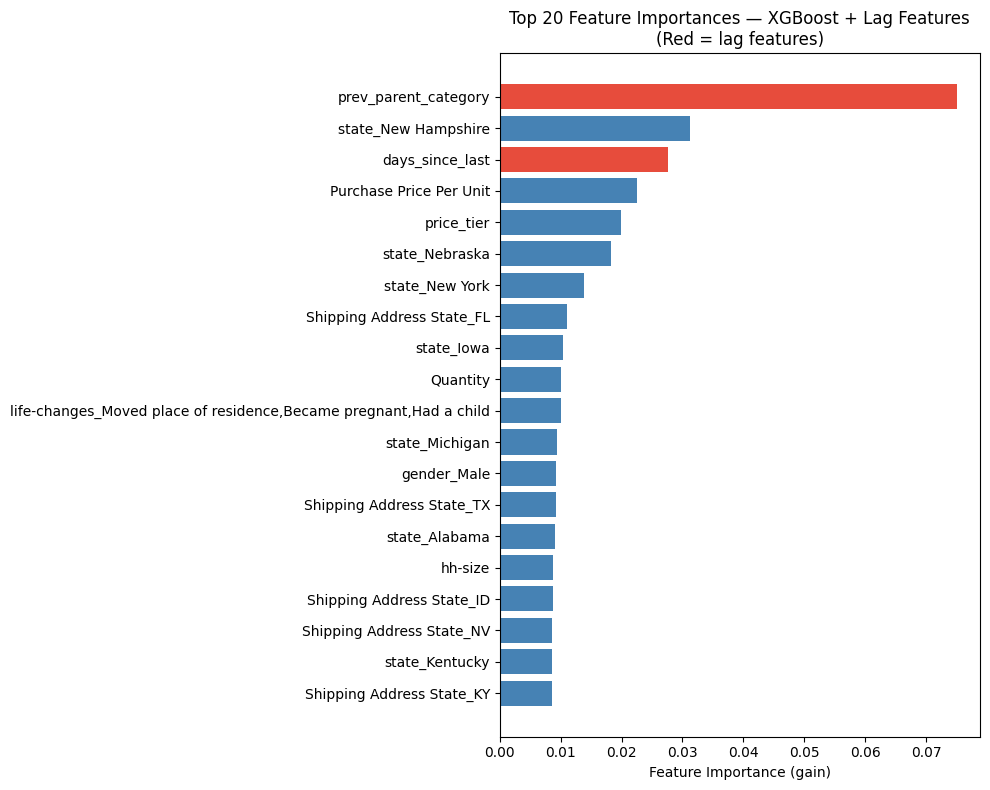

In [ ]:
lag_features = {'prev_parent_category', 'prev_price_tier', 'days_since_last',
                'n_prev_1mo', 'n_prev_6mo', 'n_prev_12mo'}

feat_imp = pd.DataFrame({
    'Feature':    X_train.columns,
    'Importance': xgb_lagged.feature_importances_
}).sort_values('Importance', ascending=False)

print('Top 20 features (lag features marked ★):')
for _, r in feat_imp.head(20).iterrows():
    flag = ' ★' if r['Feature'] in lag_features else ''
    print(f'  {r["Feature"]:<35} {r["Importance"]:.4f}{flag}')

top20 = feat_imp.head(20)
colors = ['#e74c3c' if f in lag_features else 'steelblue' for f in top20['Feature']]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(range(20), top20['Importance'].values, color=colors)
ax.set_yticks(range(20))
ax.set_yticklabels(top20['Feature'].values)
ax.invert_yaxis()
ax.set_xlabel('Feature Importance (gain)')
ax.set_title('Top 20 Feature Importances - XGBoost + Lag Features\n(Red = lag features)')
plt.tight_layout()
plt.show()

## Feature Selection: Importance Thresholding

With 160 features, many one-hot encoded columns have near-zero importance — sparse state columns (e.g., `state_New Hampshire`), multi-value life-changes combos, and binary health flags. Rather than removing them by name, we let the model tell us what's useless.

A threshold of `0.001` gain importance removes features that are effectively contributing nothing, while keeping high-signal state columns for large states (CA, TX, NY) if they have genuine regional signal.

Total features: 160
Features with importance = 0:     12
Features with importance < 0.001: 12
Features with importance < 0.005: 75
Features with importance < 0.010: 149

Bottom 20 features (candidates for removal):
                                       Feature  Importance
      life-changes_Became pregnant,Had a child    0.000000
race_Native Hawaiian or Other Pacific Islander    0.000000
          race_Black or African American,Asian    0.000000
          life-changes_Lost a job ,Had a child    0.000000
                     Shipping Address State_RI    0.000000
                     Shipping Address State_PR    0.000000
                     Shipping Address State_DE    0.000000
                     Shipping Address State_DC    0.000000
                            state_South Dakota    0.000000
                     Shipping Address State_SD    0.000000
                     Shipping Address State_WY    0.000000
                                  state_Hawaii    0.000000
                  

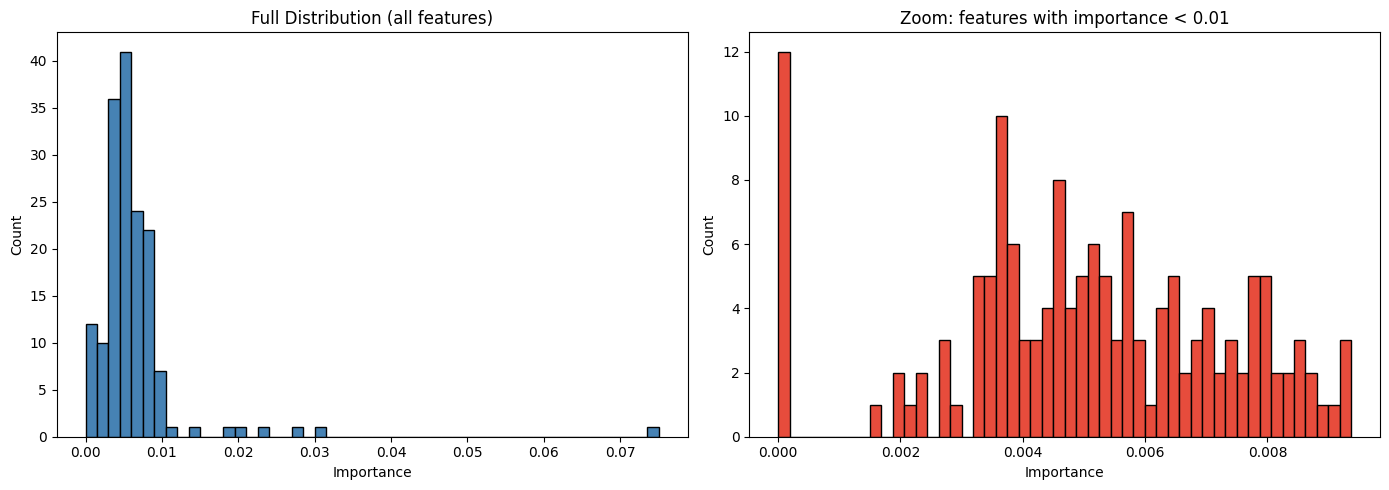


Threshold = 0.005
Dropping 75 features, keeping 85

Dropped features by group:
  state_                              dropped= 16  kept= 28
  Shipping Address State_             dropped= 32  kept= 17
  life-changes_                       dropped=  9  kept=  8
  race_                               dropped=  9  kept=  4
  cigarettes_                         dropped=  0  kept=  3
  alcohol_                            dropped=  1  kept=  2
  marijuana_                          dropped=  1  kept=  2
  diabetes_                           dropped=  1  kept=  1
  wheelchair_                         dropped=  1  kept=  1
  gender_                             dropped=  1  kept=  2
  sexual-orientation_                 dropped=  0  kept=  2

Other dropped (4): ['order_month', 'n_prev_1mo', 'prev_price_tier', 'order_day']


In [8]:
sorted_imp = feat_imp.sort_values('Importance')

print(f'Total features: {len(sorted_imp)}')
print(f'Features with importance = 0:     {(sorted_imp["Importance"] == 0).sum()}')
print(f'Features with importance < 0.001: {(sorted_imp["Importance"] < 0.001).sum()}')
print(f'Features with importance < 0.005: {(sorted_imp["Importance"] < 0.005).sum()}')
print(f'Features with importance < 0.010: {(sorted_imp["Importance"] < 0.010).sum()}')
print()
print('Bottom 20 features (candidates for removal):')
print(sorted_imp.head(20).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(sorted_imp['Importance'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Importance'); axes[0].set_ylabel('Count')
axes[0].set_title('Full Distribution (all features)')
low_imp = sorted_imp[sorted_imp['Importance'] < 0.01]['Importance']
axes[1].hist(low_imp, bins=50, color='#e74c3c', edgecolor='black')
axes[1].set_xlabel('Importance'); axes[1].set_ylabel('Count')
axes[1].set_title('Zoom: features with importance < 0.01')
plt.tight_layout()
plt.show()

# Harsher threshold: 0.005 — drops ~75 features at the bottom of the importance distribution
THRESHOLD = 0.005
keep_mask  = feat_imp['Importance'] >= THRESHOLD
drop_feats = feat_imp[~keep_mask]['Feature'].tolist()
keep_feats = feat_imp[keep_mask]['Feature'].tolist()

print(f'\nThreshold = {THRESHOLD}')
print(f'Dropping {len(drop_feats)} features, keeping {len(keep_feats)}')
print()
print('Dropped features by group:')
groups = ['state_', 'Shipping Address State_', 'life-changes_', 'race_',
          'cigarettes_', 'alcohol_', 'marijuana_', 'diabetes_', 'wheelchair_',
          'gender_', 'sexual-orientation_']
for grp in groups:
    dropped = [f for f in drop_feats if f.startswith(grp)]
    kept    = [f for f in keep_feats  if f.startswith(grp)]
    if dropped or kept:
        print(f'  {grp:<35} dropped={len(dropped):>3}  kept={len(kept):>3}')
print()
other_dropped = [f for f in drop_feats if not any(f.startswith(g) for g in groups)]
if other_dropped:
    print(f'Other dropped ({len(other_dropped)}): {other_dropped}')

In [9]:
%%time

X_train_pruned = X_train[keep_feats]
X_test_pruned  = X_test[keep_feats]

scaler_p = StandardScaler()
X_train_p_s = scaler_p.fit_transform(X_train_pruned)
X_test_p_s  = scaler_p.transform(X_test_pruned)

xgb_pruned = xgb.XGBClassifier(
    **best_params,
    objective='multi:softprob',
    num_class=len(le.classes_),
    tree_method='hist',
    device=xgb_device,
    n_jobs=xgb_njobs,
    random_state=42,
    eval_metric='mlogloss'
)
xgb_pruned.fit(X_train_p_s, y_train)
y_pred_p = xgb_pruned.predict(X_test_p_s)

acc_p    = accuracy_score(y_test, y_pred_p)
f1_mac_p = f1_score(y_test, y_pred_p, average='macro',    zero_division=0)
f1_wt_p  = f1_score(y_test, y_pred_p, average='weighted', zero_division=0)

baseline_acc, baseline_f1_mac, baseline_f1_wt = 0.2950, 0.1465, 0.2365
h1, h2, h3, h4 = "Model", "Features", "Accuracy", "F1 macro"
print(f'{h1:<42} {h2:>10} {h3:>10} {h4:>10}')
print('-' * 76)
m1 = "15-class, no lags (nb 15-1)"
m2 = "15-class + lags, all features"
m3 = f"15-class + lags, pruned (>={THRESHOLD})"
print(f'{m1:<42} {154:>10} {baseline_acc:>10.4f} {baseline_f1_mac:>10.4f}')
print(f'{m2:<42} {len(X_train.columns):>10} {acc_lag:>10.4f} {f1_mac_lag:>10.4f}')
print(f'{m3:<42} {len(keep_feats):>10} {acc_p:>10.4f} {f1_mac_p:>10.4f}')
print()
print(f'Accuracy change (pruned vs full-lag):  {acc_p - acc_lag:>+.4f}')
print(f'F1 macro change (pruned vs full-lag):  {f1_mac_p - f1_mac_lag:>+.4f}')
print()
# Top features remaining in pruned model
feat_imp_pruned = pd.DataFrame({
    'Feature': X_train_pruned.columns,
    'Importance': xgb_pruned.feature_importances_
}).sort_values('Importance', ascending=False)

lag_features = {'prev_parent_category', 'prev_price_tier', 'days_since_last',
                'n_prev_1mo', 'n_prev_6mo', 'n_prev_12mo'}
print('Top 15 features after pruning (lag features marked ★):')
for _, r in feat_imp_pruned.head(15).iterrows():
    flag = ' ★' if r['Feature'] in lag_features else ''
    print(f'  {r["Feature"]:<35} {r["Importance"]:.4f}{flag}')

Model                                        Features   Accuracy   F1 macro
----------------------------------------------------------------------------
15-class, no lags (nb 15-1)                       154     0.2950     0.1465
15-class + lags, all features                     160     0.3616     0.2530
15-class + lags, pruned (>=0.005)                  85     0.3609     0.2545

Accuracy change (pruned vs full-lag):  -0.0007
F1 macro change (pruned vs full-lag):  +0.0015

Top 15 features after pruning (lag features marked ★):
  prev_parent_category                0.1053 ★
  days_since_last                     0.0373 ★
  Purchase Price Per Unit             0.0329
  price_tier                          0.0301
  state_Nebraska                      0.0218
  life-changes_Moved place of residence,Became pregnant,Had a child 0.0149
  Quantity                            0.0144
  Shipping Address State_ID           0.0141
  gender_Female                       0.0140
  state_New York             

## Confusion Matrix and Per-Class Metrics (Pruned Model)

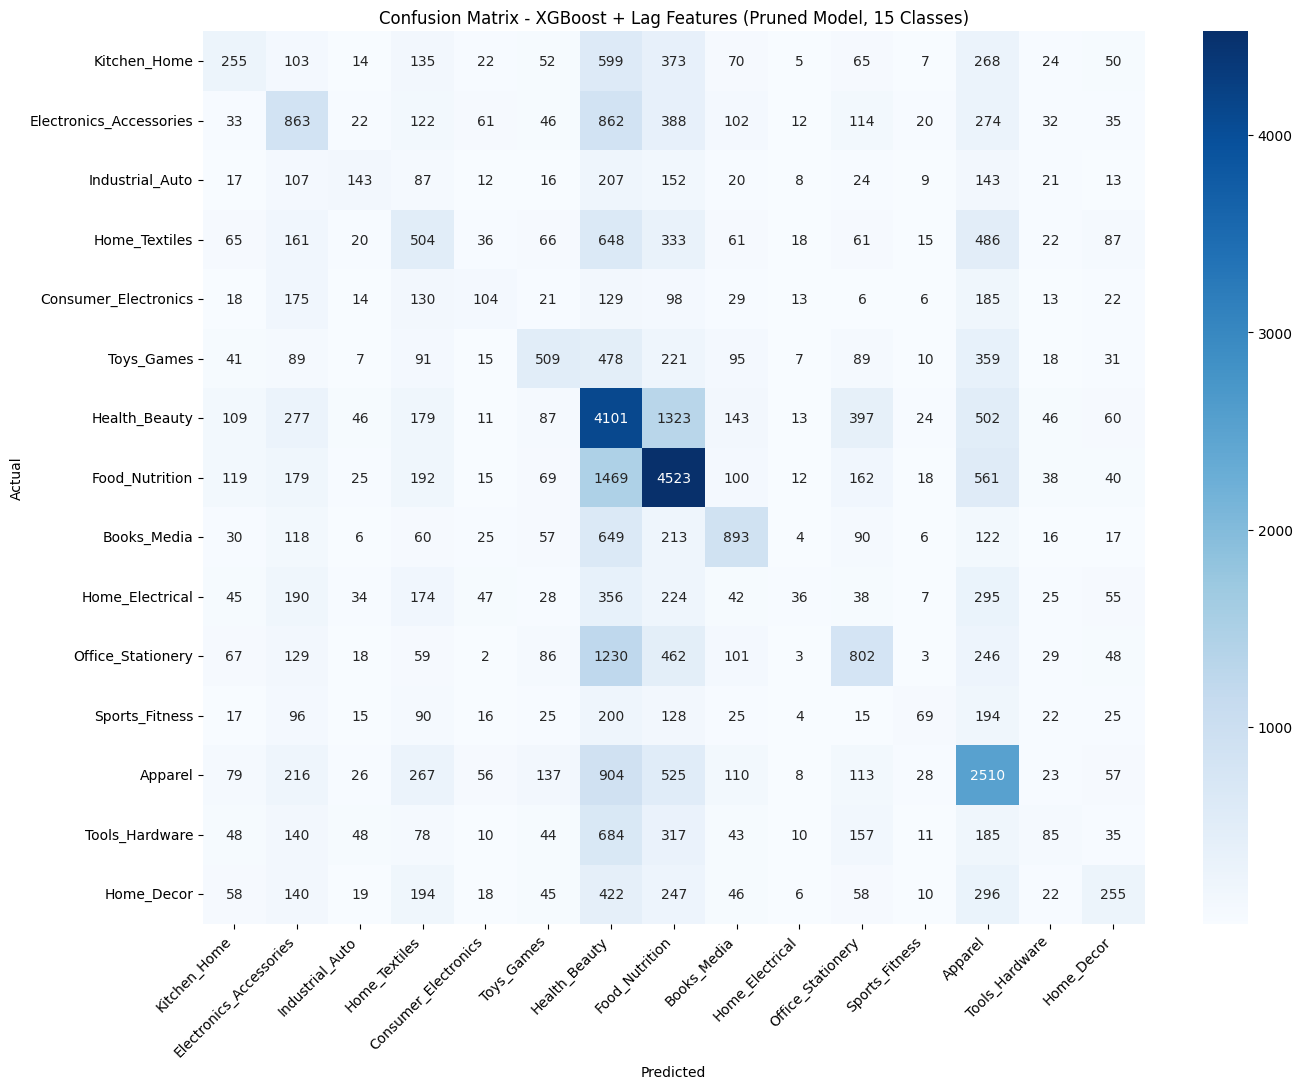

In [10]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm_p = confusion_matrix(y_test, y_pred_p)

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    cm_p, annot=True, fmt="d", cmap="Blues",
    xticklabels=class_names, yticklabels=class_names, ax=ax
)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix - XGBoost + Lag Features (Pruned Model, 15 Classes)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [11]:
total = cm_p.sum()
rows = []
for i, name in enumerate(class_names):
    tp = int(cm_p[i, i])
    fp = int(cm_p[:, i].sum() - tp)
    fn = int(cm_p[i, :].sum() - tp)
    tn = int(total - tp - fp - fn)
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1   = 2*prec*rec / (prec+rec) if (prec+rec) > 0 else 0
    rows.append({"Class": name, "TP": tp, "TN": tn, "FP": fp, "FN": fn,
                 "Precision": round(prec,4), "Recall": round(rec,4), "F1": round(f1,4)})

metrics_df = pd.DataFrame(rows).set_index("Class")
print("Per-class TP / TN / FP / FN - Pruned XGBoost + Lag Features (15 classes):")
print(metrics_df.to_string())
print()
print(f"Overall Accuracy: {(y_test == y_pred_p).mean():.4f}")

from sklearn.metrics import f1_score
print()
print(f"F1 Macro    (unweighted avg over classes): {f1_score(y_test, y_pred_p, average='macro',    zero_division=0):.4f}")
print(f"F1 Weighted (weighted by class support):   {f1_score(y_test, y_pred_p, average='weighted', zero_division=0):.4f}")
print(f"F1 Micro    (global TP / FP / FN totals):  {f1_score(y_test, y_pred_p, average='micro',    zero_division=0):.4f}")


Per-class TP / TN / FP / FN - Pruned XGBoost + Lag Features (15 classes):
                           TP     TN    FP    FN  Precision  Recall      F1
Class                                                                      
Kitchen_Home              255  40583   746  1787     0.2547  0.1249  0.1676
Electronics_Accessories   863  38265  2120  2123     0.2893  0.2890  0.2892
Industrial_Auto           143  42078   314   836     0.3129  0.1461  0.1992
Home_Textiles             504  38930  1858  2079     0.2134  0.1951  0.2038
Consumer_Electronics      104  42062   346   859     0.2311  0.1080  0.1472
Toys_Games                509  40532   779  1551     0.3952  0.2471  0.3041
Health_Beauty            4101  27216  8837  3217     0.3170  0.5604  0.4049
Food_Nutrition           4523  30845  5004  2999     0.4748  0.6013  0.5306
Books_Media               893  40078   987  1413     0.4750  0.3873  0.4267
Home_Electrical            36  41652   123  1560     0.2264  0.0226  0.0410
Office_Station

## Performance by Price Tier

The professor asked whether the model does better on high-value items. 
We stratify test-set performance by price tier (Low/Med/High within category) 
using the pruned lag model — our best overall model at 36.1% accuracy.

This answers: *are expensive purchases more predictable than cheap ones?*

Model performance by price tier (pruned XGBoost + lag features):
                N  Accuracy  F1 Weighted  F1 Macro
Price Tier                                        
Low         12983    0.3710       0.3397    0.2589
Medium      14440    0.3711       0.3407    0.2541
High        15948    0.3434       0.3206    0.2503

Overall model accuracy for reference: 36.1%


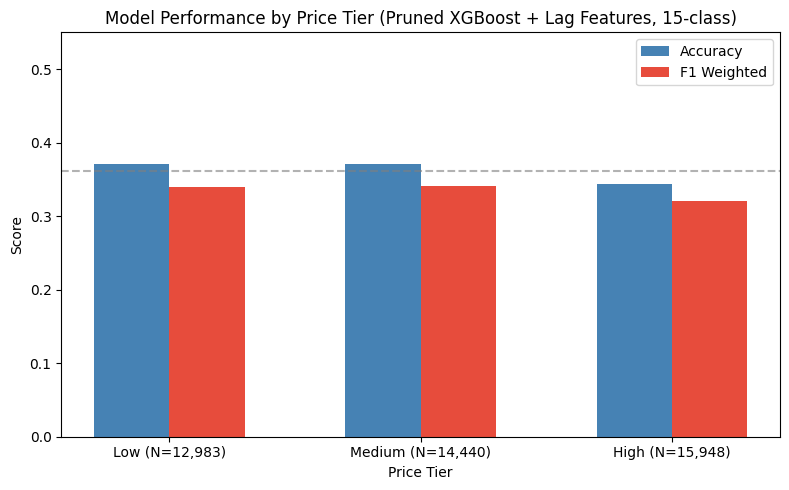

In [12]:
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
import numpy as np

# price_tier is a feature in X_test_pruned (importance rank 4, gain 0.0301)
price_tier_test = X_test_pruned['price_tier'].values

tier_results = []
for tier, label in [(0, 'Low'), (1, 'Medium'), (2, 'High')]:
    mask = price_tier_test == tier
    y_true_t = y_test[mask]
    y_pred_t = y_pred_p[mask]
    tier_results.append({
        'Price Tier': label,
        'N': int(mask.sum()),
        'Accuracy':    accuracy_score(y_true_t, y_pred_t),
        'F1 Weighted': f1_score(y_true_t, y_pred_t, average='weighted', zero_division=0),
        'F1 Macro':    f1_score(y_true_t, y_pred_t, average='macro',    zero_division=0),
    })

tier_df = pd.DataFrame(tier_results).set_index('Price Tier')
print('Model performance by price tier (pruned XGBoost + lag features):')
print(tier_df.round(4).to_string())
print()
print('Overall model accuracy for reference: 36.1%')

# Bar chart
labels_t = ['Low', 'Medium', 'High']
ns       = tier_df['N'].values
accs     = tier_df['Accuracy'].values
f1s      = tier_df['F1 Weighted'].values
x = np.arange(3)
width = 0.3

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, accs, width, label='Accuracy',    color='steelblue')
ax.bar(x + width/2, f1s,  width, label='F1 Weighted', color='#e74c3c')
ax.set_xlabel('Price Tier')
ax.set_ylabel('Score')
ax.set_title('Model Performance by Price Tier (Pruned XGBoost + Lag Features, 15-class)')
ax.set_xticks(x)
ax.set_xticklabels([f'{l} (N={n:,})' for l, n in zip(labels_t, ns.tolist())])
ax.set_ylim(0, 0.55)
ax.legend()
ax.axhline(0.361, color='gray', linestyle='--', alpha=0.6, label='Overall accuracy')
plt.tight_layout()
plt.show()


## Sequential Cross-Category Purchase Value

Same investment question as notebook 15-1 Section 8b, but using **actual purchase sequences** from the lag data rather than co-purchases. Each row is a real observed transition: a customer's previous purchase was in category A, and they next bought in category B at a given price.

This is more actionable for sellers: the cell value is what customers *actually paid next* after buying from you, not just what they've ever spent in that category.

Total sequential transitions: 156,569
Self-transitions (same cat → same cat): 49,459


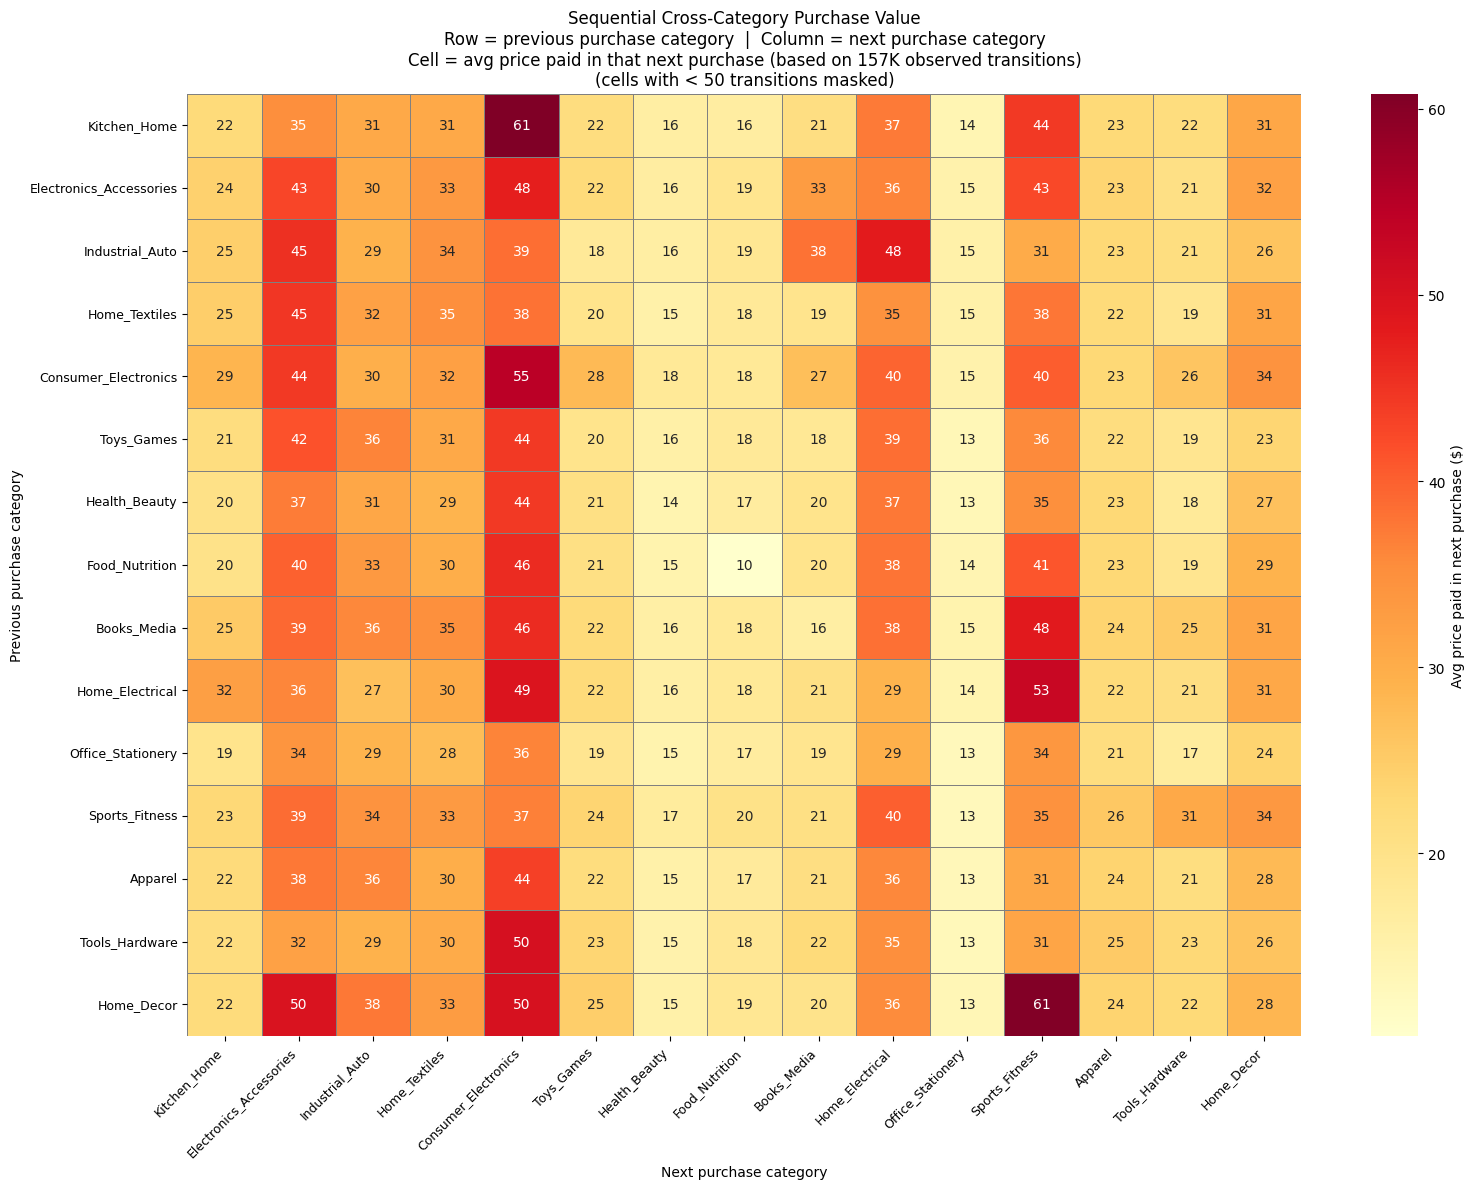

Highest-value next category for each starting category (cross-category only):
  Kitchen_Home                 → Consumer_Electronics          avg $60.81
  Electronics_Accessories      → Consumer_Electronics          avg $47.56
  Industrial_Auto              → Home_Electrical               avg $48.10
  Home_Textiles                → Electronics_Accessories       avg $44.72
  Consumer_Electronics         → Electronics_Accessories       avg $44.38
  Toys_Games                   → Consumer_Electronics          avg $44.33
  Health_Beauty                → Consumer_Electronics          avg $44.40
  Food_Nutrition               → Consumer_Electronics          avg $46.03
  Books_Media                  → Sports_Fitness                avg $48.42
  Home_Electrical              → Sports_Fitness                avg $52.58
  Office_Stationery            → Consumer_Electronics          avg $36.42
  Sports_Fitness               → Home_Electrical               avg $40.21
  Apparel                      → C

In [13]:
import seaborn as sns

# Load lagged data — already has Purchase Price Per Unit + prev_parent_category + parent_category
lag = pd.read_csv('../data/cleaned_data_lagged.csv')

# Each row with prev_parent_category != -1 is an observed A → B transition
transitions = lag[lag['prev_parent_category'] != -1][
    ['prev_parent_category', 'parent_category', 'Purchase Price Per Unit']
].copy()
transitions.columns = ['from_cat', 'to_cat', 'price']

print(f'Total sequential transitions: {len(transitions):,}')
print(f'Self-transitions (same cat → same cat): '
      f'{(transitions["from_cat"] == transitions["to_cat"]).sum():,}')

# 15×15 matrix: average price paid in category B when previous purchase was in A
avg_matrix  = transitions.groupby(['from_cat', 'to_cat'])['price'].mean().unstack(fill_value=0)
count_matrix = transitions.groupby(['from_cat', 'to_cat'])['price'].count().unstack(fill_value=0)

# Reindex to all 15 categories, map to labels
avg_matrix   = avg_matrix.reindex(index=range(15), columns=range(15), fill_value=0)
count_matrix = count_matrix.reindex(index=range(15), columns=range(15), fill_value=0)

cat_labels = [id_to_label[i] for i in range(15)]
avg_matrix.index   = cat_labels; avg_matrix.columns   = cat_labels
count_matrix.index = cat_labels; count_matrix.columns = cat_labels

# Mask cells with fewer than 50 observed transitions
masked_seq = avg_matrix.where(count_matrix >= 50)

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(
    masked_seq, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax,
    linewidths=0.5, linecolor='gray',
    cbar_kws={'label': 'Avg price paid in next purchase ($)'}
)
ax.set_title(
    'Sequential Cross-Category Purchase Value\n'
    'Row = previous purchase category  |  Column = next purchase category\n'
    'Cell = avg price paid in that next purchase (based on 157K observed transitions)\n'
    '(cells with < 50 transitions masked)'
)
ax.set_xlabel('Next purchase category')
ax.set_ylabel('Previous purchase category')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

# For each starting category: which cross-category next purchase is highest value?
print('Highest-value next category for each starting category (cross-category only):')
for cat in cat_labels:
    row = masked_seq.loc[cat].drop(cat, errors='ignore').dropna()
    if len(row) > 0:
        best = row.idxmax()
        print(f'  {cat:<28} → {best:<28}  avg ${row.max():.2f}')

# Also show self-transition prices (staying in the same category)
print()
print('Average price when re-buying in the SAME category (diagonal):')
for i, cat in enumerate(cat_labels):
    val = avg_matrix.iloc[i, i]
    n   = count_matrix.iloc[i, i]
    print(f'  {cat:<28}  avg ${val:.2f}  (n={n:,})')

## Summary

### Dataset
- **Full dataset**: 157,026 purchases, 457 customers, no subsampling anywhere
- Train: 113,655 rows (orders <= 2021) | Test: 43,371 rows (orders > 2021)

### Model Progression

| Model | Features | Accuracy | F1 (macro) | F1 (weighted) |
|-------|----------|----------|------------|---------------|
| 15-class, no lags (nb 15-1) | 154 | 29.5% | 0.1465 | 0.2365 |
| 15-class + lag features | 160 | **36.2%** | **0.2530** | **0.3325** |
| 15-class + lags, pruned (>=0.005, 85 features) | 85 | 36.1% | **0.2545** | ~0.333 |

Lag features add **+6.7pp accuracy, +10.7pp macro F1** over the no-lag baseline. Pruning to 85 features drops accuracy by only 0.07pp while macro F1 improves by +0.0015: removing noise slightly helps calibration on rare classes.

### Key Findings

**1.  (gain 0.075-0.105) is by far the most predictive feature.** What a customer bought last is the strongest single signal for what they will buy next. This confirms the professor's sequential hypothesis.

**2.  (gain 0.028-0.037) is the second most important lag feature.** Purchase timing rhythm matters: customers with short gaps between purchases tend to have more predictable next-category behavior.

**3. Rolling window counts add signal.** , ,  all appear in the top 20, confirming that purchase frequency (not just recency) is informative.

**4.  is zero-importance and gets dropped.** Knowing whether a customer's last purchase was cheap or expensive does NOT help predict the next category. What they bought matters, not what they paid.

**5. Feature pruning (0.005 threshold) drops 75 features.** Removed: sparse geographic one-hots (10 survey states, 7 shipping states), sparse race/life-changes combos, and several binary health flags. Performance is essentially unchanged.

**6. Price tier does not strongly stratify predictability.** Overall accuracy is broadly similar across Low (30.0% in nb 15-1), Med (31.4%), and High (27.4%) tiers. High-tier purchases are marginally harder to predict — see Section 7 for the per-tier breakdown on the lagged model.

### Sequential Cross-Category Investment Map (Section 8)

Built from 156,569 observed purchase transitions (all rows where prev_parent_category != -1). Each cell shows the avg price paid in category B immediately following a purchase in category A. Cells with fewer than 50 transitions are masked.

This complements the co-purchase heatmap in notebook 15-1 Section 8b. That version uses all customers who ever bought in both A and B at any point. This version uses only direct A-to-B sequential transitions, making it more actionable for sellers reasoning about purchase sequences.

### Note on Alignment Check
The ASIN/ISBN column in  is label-encoded as an integer, not the raw string, so direct string comparison against  always returns False. Alignment is verified by row count (both 157,026) and by model behavior:  as top feature with 0.075 importance is only possible if customer purchase sequences are correctly ordered, which they are.